/tmp/ipykernel_514/4010286009.py:68: RuntimeWarning: invalid value encountered in divide
  plt.quiver(X0,X1,dX0/M,dX1/M,color='b')
/tmp/ipykernel_514/4010286009.py:83: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(x_right, -(1+np.sqrt(-4*(x_right)**4+4*(x_right)**2+1))/(2*(x_right)), color='k',linewidth=4, label='x nullcline')
/tmp/ipykernel_514/4010286009.py:84: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(x_right, -(1-np.sqrt(-4*(x_right)**4+4*(x_right)**2+1))/(2*(x_right)), color='k',linewidth=4)
/tmp/ipykernel_514/4010286009.py:85: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(x_left, -(1+np.sqrt(-4*(x_left)**4+4*(x_left)**2+1))/(2*(x_left)), color='k',linewidth=4)
/tmp/ipykernel_514/4010286009.py:86: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(x_left, -(1-np.sqrt(-4*(x_left)**4+4*(x_left)**2+1))/(2*(x_left)), color='k',linewidth=4)
/tmp/ipykernel_514/4010286009.py:91: RuntimeWarning: invalid value encountered in sqrt
 

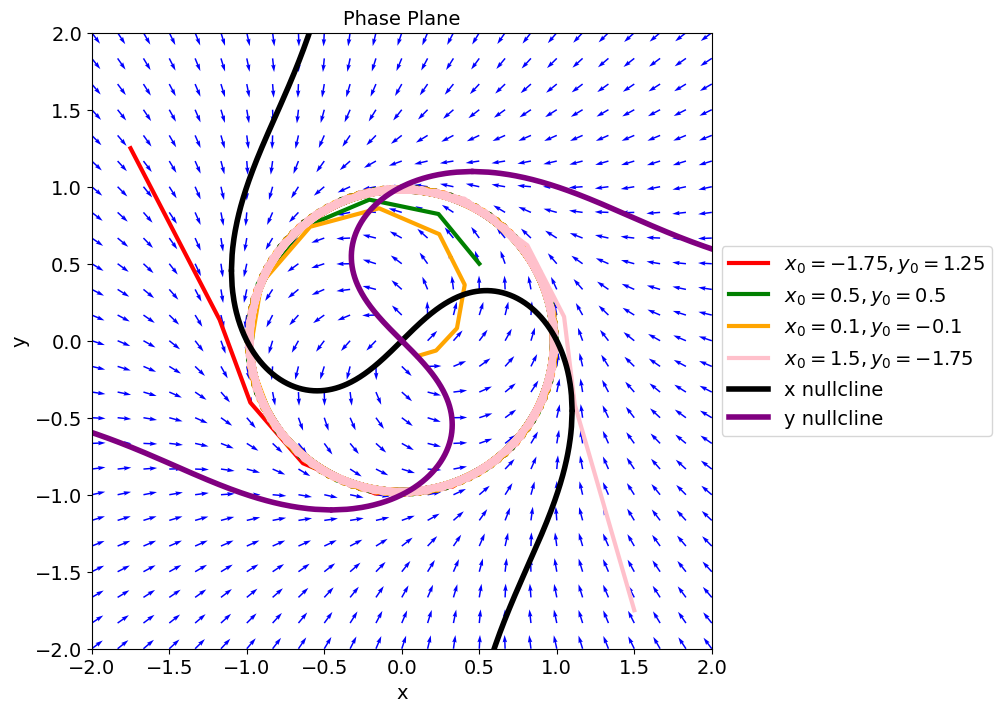

In [4]:
##Note: The code for the phase plane and state-space trajectory is taken from:
#https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/#google_vignette$0

import matplotlib.pyplot as plt
from scipy.integrate import odeint
import numpy as np

# first create create a function that evaluates the right-hand-side of the
# state-space equations for a given state vector

# x is the current state vector
# t is current simulation time

def dynamicsStateSpace(x,t):
    dxdt=[-x[1]+x[0]*(1-x[0]**2-x[1]**2),x[0]+x[1]*(1-x[0]**2-x[1]**2)]
    return dxdt

# next, define a grid of points at which we will show arrows
x0=np.linspace(-2,2,25)
x1=np.linspace(-2,2,25)

# create a grid
X0,X1=np.meshgrid(x0,x1)
# projections of the trajectory tangent vector
dX0=np.zeros(X0.shape)
dX1=np.zeros(X1.shape)

shape1,shape2=X1.shape

for indexShape1 in range(shape1):
    for indexShape2 in range(shape2):
        dxdtAtX=dynamicsStateSpace([X0[indexShape1,indexShape2],X1[indexShape1,indexShape2]],0)
        dX0[indexShape1,indexShape2]=dxdtAtX[0]
        dX1[indexShape1,indexShape2]=dxdtAtX[1]

# Calculate the magnitude of the vectors (so vectors in phase plot are all the same size)
M = (dX0**2 + dX1**2)**0.5


# plot the dynamics on the same graph
initialState_1=np.array([-1.75,1.25])
simulationTime_1=np.linspace(0,50,100)
# generate the state-space trajectory
solutionState_1=odeint(dynamicsStateSpace,initialState_1,simulationTime_1)

# plot the dynamics on the same graph
initialState_2=np.array([0.5,0.5])
simulationTime_2=np.linspace(0,50,100)
# generate the state-space trajectory
solutionState_2=odeint(dynamicsStateSpace,initialState_2,simulationTime_2)

# plot the dynamics on the same graph
initialState_3=np.array([0.1,-0.1])
simulationTime_3=np.linspace(0,50,100)
# generate the state-space trajectory
solutionState_3=odeint(dynamicsStateSpace,initialState_3,simulationTime_3)

# plot the dynamics on the same graph
initialState_4=np.array([1.5,-1.75])
simulationTime_4=np.linspace(0,50,100)
# generate the state-space trajectory
solutionState_4=odeint(dynamicsStateSpace,initialState_4,simulationTime_4)


#adjust the figure size
plt.figure(figsize=(8, 8))
# plot the phase portrait
plt.quiver(X0,X1,dX0/M,dX1/M,color='b')
# adjust the axis limits
plt.xlim(-2,2)
plt.ylim(-2,2)
# add the state trajectory plot
plt.plot(solutionState_1[:,0], solutionState_1[:,1], color='r',linewidth=3, label=f'$x_0=-1.75, y_0=1.25$')
plt.plot(solutionState_2[:,0], solutionState_2[:,1], color='g',linewidth=3, label=f'$x_0=0.5, y_0=0.5$')
plt.plot(solutionState_3[:,0], solutionState_3[:,1], color='orange',linewidth=3, label=f'$x_0=0.1, y_0=-0.1$')
plt.plot(solutionState_4[:,0], solutionState_4[:,1], color='pink',linewidth=3, label=f'$x_0=1.5, y_0=-1.75$')

# add the nullclines

#x nullcline
x_right=np.linspace(0.001,2,500) #Have to get as close as possible to 0 (but undefined at 0)
x_left=np.linspace(-2,-0.001,500) #Consists of two functions, have to consider both pieces
plt.plot(x_right, -(1+np.sqrt(-4*(x_right)**4+4*(x_right)**2+1))/(2*(x_right)), color='k',linewidth=4, label='x nullcline')
plt.plot(x_right, -(1-np.sqrt(-4*(x_right)**4+4*(x_right)**2+1))/(2*(x_right)), color='k',linewidth=4)
plt.plot(x_left, -(1+np.sqrt(-4*(x_left)**4+4*(x_left)**2+1))/(2*(x_left)), color='k',linewidth=4)
plt.plot(x_left, -(1-np.sqrt(-4*(x_left)**4+4*(x_left)**2+1))/(2*(x_left)), color='k',linewidth=4)

#y nullcline
y_right=np.linspace(0.001,2,500) #Have to get as close as possible to 0 (but undefined at 0)
y_left=np.linspace(-2,-0.001,500) #Consists of two functions, have to consider both pieces
plt.plot(-(-1-np.sqrt(-4*(y_right)**4+4*(y_right)**2+1))/(2*(y_right)), y_right, color='purple',linewidth=4, label='y nullcline')
plt.plot( -(-1+np.sqrt(-4*(y_right)**4+4*(y_right)**2+1))/(2*(y_right)), y_right, color='purple',linewidth=4)
plt.plot(-(-1+np.sqrt(-4*(y_left)**4+4*(y_left)**2+1))/(2*(y_left)), y_left, color='purple',linewidth=4)
plt.plot(-(-1-np.sqrt(-4*(y_left)**4+4*(y_left)**2+1))/(2*(y_left)), y_left, color='purple',linewidth=4)


# insert the title
plt.title('Phase Plane', fontsize=14)
# set the axis labels
plt.xlabel('x',fontsize=14)
plt.ylabel('y',fontsize=14)
# adjust the font size of x and y axes
plt.tick_params(axis='both', which='major', labelsize=14)
# insert legend
plt.legend(fontsize=14, loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

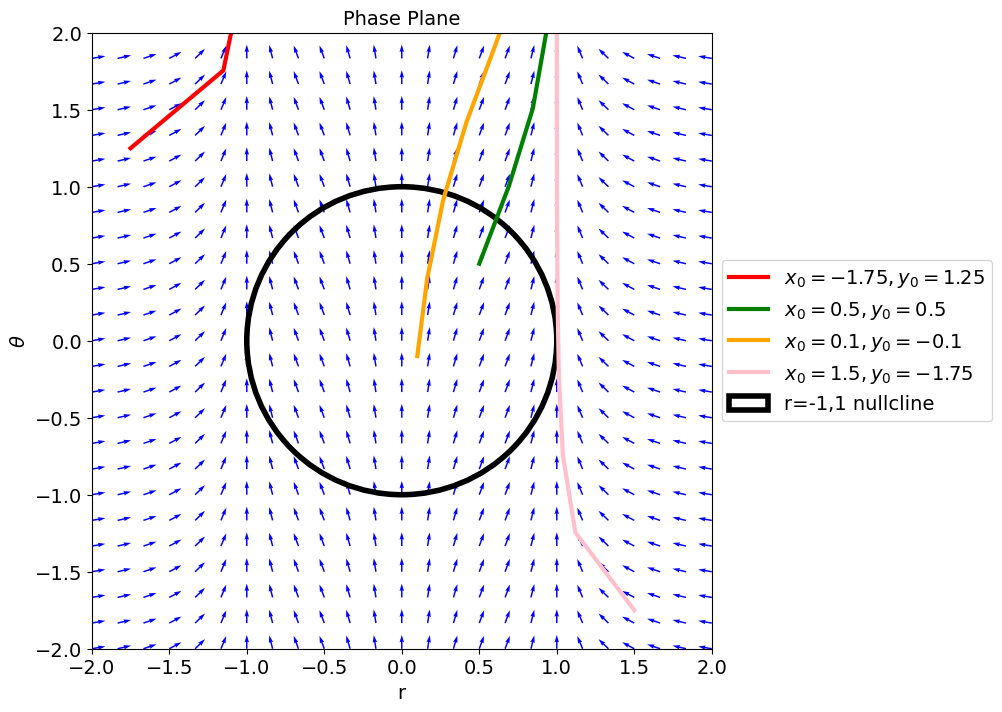

In [6]:
##Note: The code for the phase plane and state-space trajectory is taken from:
#https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/#google_vignette$0

import matplotlib.pyplot as plt
from scipy.integrate import odeint
import numpy as np

# first create create a function that evaluates the right-hand-side of the
# state-space equations for a given state vector

# x is the current state vector
# t is current simulation time

def dynamicsStateSpace(x,t):
    dxdt=[x[0]*(1-x[0]**2),1]
    return dxdt

# next, define a grid of points at which we will show arrows
x0=np.linspace(-2,2,25)
x1=np.linspace(-2,2,25)

# create a grid
X0,X1=np.meshgrid(x0,x1)
# projections of the trajectory tangent vector
dX0=np.zeros(X0.shape)
dX1=np.zeros(X1.shape)

shape1,shape2=X1.shape

for indexShape1 in range(shape1):
    for indexShape2 in range(shape2):
        dxdtAtX=dynamicsStateSpace([X0[indexShape1,indexShape2],X1[indexShape1,indexShape2]],0)
        dX0[indexShape1,indexShape2]=dxdtAtX[0]
        dX1[indexShape1,indexShape2]=dxdtAtX[1]

# Calculate the magnitude of the vectors (so vectors in phase plot are all the same size)
M = (dX0**2 + dX1**2)**0.5


# plot the dynamics on the same graph
initialState_1=np.array([-1.75,1.25])
simulationTime_1=np.linspace(0,50,100)
# generate the state-space trajectory
solutionState_1=odeint(dynamicsStateSpace,initialState_1,simulationTime_1)

# plot the dynamics on the same graph
initialState_2=np.array([0.5,0.5])
simulationTime_2=np.linspace(0,50,100)
# generate the state-space trajectory
solutionState_2=odeint(dynamicsStateSpace,initialState_2,simulationTime_2)

# plot the dynamics on the same graph
initialState_3=np.array([0.1,-0.1])
simulationTime_3=np.linspace(0,50,100)
# generate the state-space trajectory
solutionState_3=odeint(dynamicsStateSpace,initialState_3,simulationTime_3)

# plot the dynamics on the same graph
initialState_4=np.array([1.5,-1.75])
simulationTime_4=np.linspace(0,50,100)
# generate the state-space trajectory
solutionState_4=odeint(dynamicsStateSpace,initialState_4,simulationTime_4)


#adjust the figure size
plt.figure(figsize=(8, 8))
# plot the phase portrait
plt.quiver(X0,X1,dX0/M,dX1/M,color='b')
# adjust the axis limits
plt.xlim(-2,2)
plt.ylim(-2,2)
# add the state trajectory plot
plt.plot(solutionState_1[:,0], solutionState_1[:,1], color='r',linewidth=3, label=f'$x_0=-1.75, y_0=1.25$')
plt.plot(solutionState_2[:,0], solutionState_2[:,1], color='g',linewidth=3, label=f'$x_0=0.5, y_0=0.5$')
plt.plot(solutionState_3[:,0], solutionState_3[:,1], color='orange',linewidth=3, label=f'$x_0=0.1, y_0=-0.1$')
plt.plot(solutionState_4[:,0], solutionState_4[:,1], color='pink',linewidth=3, label=f'$x_0=1.5, y_0=-1.75$')


#r nullcline (theta nullcline does not exist)
# note: idea for circle was borrowed from https://stackoverflow.com/questions/9215658/plot-a-circle-with-matplotlib-pyplot$0
circle = plt.Circle((0, 0), radius=1, color='black', fill=False, linewidth=4, label='r=-1,1 nullcline')
fig = plt.gcf()
ax = fig.gca()

ax.add_patch(circle)


# insert the title
plt.title('Phase Plane', fontsize=14)
# set the axis labels
plt.xlabel('r',fontsize=14)
plt.ylabel(r'$\theta$',fontsize=14)
# adjust the font size of x and y axes
plt.tick_params(axis='both', which='major', labelsize=14)
# insert legend
plt.legend(fontsize=14, loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()